In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
from datetime import datetime
import pytz
import ipywidgets as widgets
from IPython.display import display

In [2]:
#load the dataset
df= pd.read_csv("googleplaystore.csv",
                  engine="python",
                  on_bad_lines="skip")
print(df.shape)

(8216, 13)


In [3]:
df

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8211,ACCDB MDB DB Manager Pro - Editor for MS Access,PRODUCTIVITY,3.1,19,4.5M,500+,Paid,$8.99,Everyone,Productivity,"November 3, 2016",1.0.8,4.0 and up
8212,Scale Models DB,TOOLS,4.4,9,33M,50+,Paid,$2.99,Everyone,Tools,"May 3, 2018",0.6.2,4.3 and up
8213,DB Train Simulator,FAMILY,3.7,6514,72M,"500,000+",Free,0,Everyone,Simulation,"May 23, 2018",1.6.2,3.0 and up
8214,DB Tools,FAMILY,4.6,37,3.3M,"1,000+",Free,0,Everyone,Education,"June 17, 2014",1.9,2.2 and up


In [4]:
print(df)

                                                    App        Category  \
0        Photo Editor & Candy Camera & Grid & ScrapBook  ART_AND_DESIGN   
1                                   Coloring book moana  ART_AND_DESIGN   
2     U Launcher Lite – FREE Live Cool Themes, Hide ...  ART_AND_DESIGN   
3                                 Sketch - Draw & Paint  ART_AND_DESIGN   
4                 Pixel Draw - Number Art Coloring Book  ART_AND_DESIGN   
...                                                 ...             ...   
8211    ACCDB MDB DB Manager Pro - Editor for MS Access    PRODUCTIVITY   
8212                                    Scale Models DB           TOOLS   
8213                                 DB Train Simulator          FAMILY   
8214                                           DB Tools          FAMILY   
8215  dB Meter - measure sound & noise level in Decibel           TOOLS   

      Rating  Reviews  Size     Installs  Type  Price Content Rating  \
0        4.1      159   19M

In [5]:
ist = pytz.timezone("Asia/Kolkata")
hour = datetime.now(ist).hour

if not (18 <= hour < 21):
    print("Graph available only between 6 PM IST and 9 PM IST")
# Clean data
df = df.dropna(subset=["App", "Category", "Reviews", "Installs", "Last Updated"])

df["Reviews"] = pd.to_numeric(df["Reviews"], errors="coerce")

df["Installs"] = (
    df["Installs"]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("+", "", regex=False)
    )
df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")

df["Last Updated"] = pd.to_datetime(df["Last Updated"], errors="coerce")

In [6]:
# Filters
df = df[df["Reviews"] > 500]

df = df[
        ~df["App"].str.upper().str.startswith(("X", "Y", "Z"), na=False)
    ]

df = df[
        ~df["App"].str.contains("S", case=False, na=False)
    ]

df = df[
        df["Category"].str.upper().str.startswith(("E", "C", "B"), na=False)
    ]

In [7]:
# Category Translation
translation = {
        "BEAUTY": "सौंदर्य",
        "BUSINESS": "வணிகம்",
        "DATING": "Dating"
    }

df["Category"] = df["Category"].str.upper().replace(translation)

In [67]:
# Monthly trend
df["Month"] = (
        pd.to_datetime(df["Last Updated"])
        .dt.to_period("M")
        .dt.to_timestamp()
    )
trend = (
        df.groupby(["Month", "Category"])["Installs"]
        .sum()
        .reset_index()
    )

In [68]:
# Plot
fig = px.line(
        trend,
        x="Month",
        y="Installs",
        color="Category",
        markers=True,
        title="Total Installs Trend by Category"
    )

In [69]:
import plotly.graph_objects as go

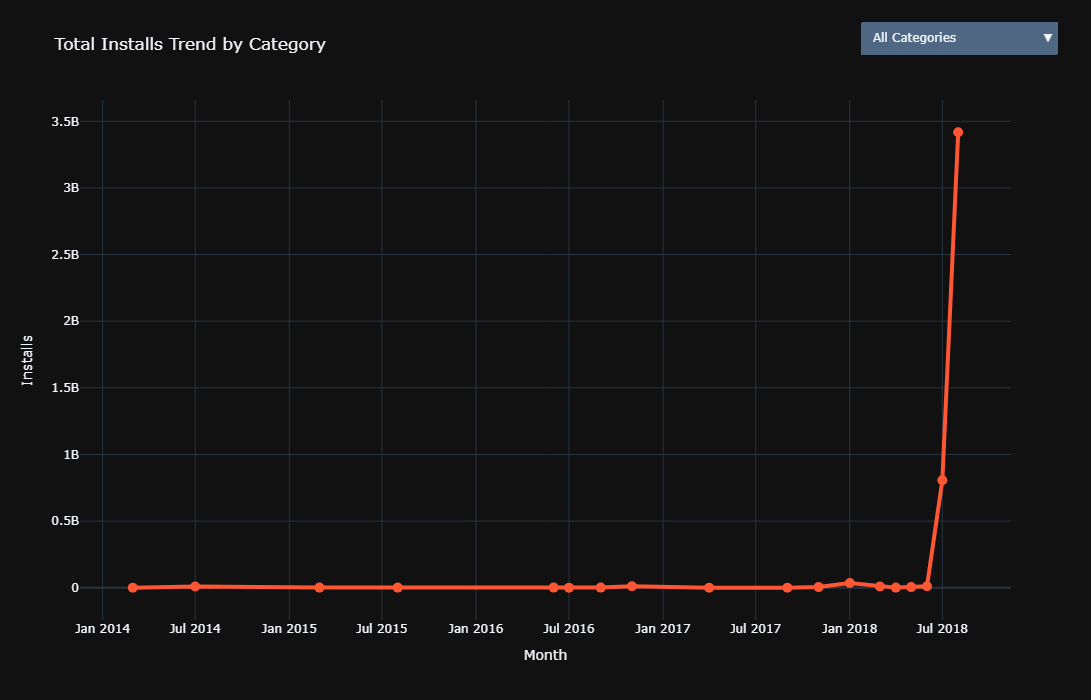

In [77]:
categories = trend["Category"].unique()

colors = [
    "#FF5733", "#33FF57", "#3357FF",
    "#FF33A8", "#F4D03F", "#8E44AD",
    "#16A085", "#D35400"
]

fig = go.Figure()

# Add traces
for i, category in enumerate(categories):

    data = trend[trend["Category"] == category]

    fig.add_trace(
        go.Scatter(
            x=data["Month"],
            y=data["Installs"],
            mode="lines+markers",
            name=category,
            visible=(i == 0),  # Show first category initially
            line=dict(
                color=colors[i % len(colors)],
                width=4
            ),
            marker=dict(
                size=10,
                color=colors[i % len(colors)]
            )
        )
    )

# Create dropdown buttons
buttons = []

for i, category in enumerate(categories):

    visible = [False] * len(categories)
    visible[i] = True

    buttons.append(
        dict(
            label=category,
            method="update",
            args=[
                {"visible": visible},
                {"title": f"{category} Install Trend"}
            ]
        )
    )

# Show all categories button
buttons.insert(
    0,
    dict(
        label="All Categories",
        method="update",
        args=[
            {"visible": [True] * len(categories)},
            {"title": "Total Installs Trend by Category"}
        ]
    )
)

fig.update_layout(
    title="Total Installs Trend by Category",
    xaxis_title="Month",
    yaxis_title="Installs",
    hovermode="x unified",
    template="plotly_dark",
    height=700,
    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            showactive=True,
            x=1.05,
            y=1.15
        )
    ]
)

fig.show()

In [78]:
fig.write_html("SeriesChart5_Plot.html")